# 🔍 Notebook 02: Exploratory Data Analysis — TB Treatment Adherence

---

## 🎯 Objetivo

Rigorous exploratory analysis of factors associated with **TB treatment dropoutmiento antituberculoso**:

1. **Distributions** of clinical and demographic variables by class
2. **Regional analysis** — where is dropout highest?
3. **Temporal analysis** — in which treatment month is dropout most common?
4. **Risk factors** — boxplots and statistical tests
5. **Correlation matrix** between variables
6. **Survival curve** — Kaplan-Meier analysis of time to dropout

### Epidemiological context
> The WHO defines "defaulter" as a patient who interrupts treatment for ≥2 months (WHO Global TB Report 2023).


In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

os.makedirs('../figures', exist_ok=True)

df = pd.read_csv('../data/processed/ml_dataset.csv',
                  parse_dates=['registration_date', 'start_date', 'end_date'])

print(f'Dataset cargado: {df.shape}')
print(f'Dropout rate: {df["dropout_label"].mean()*100:.1f}%')

Dataset cargado: (800, 71)
Dropout rate: 19.6%


## 1. Outcome Distribution and Target Variable

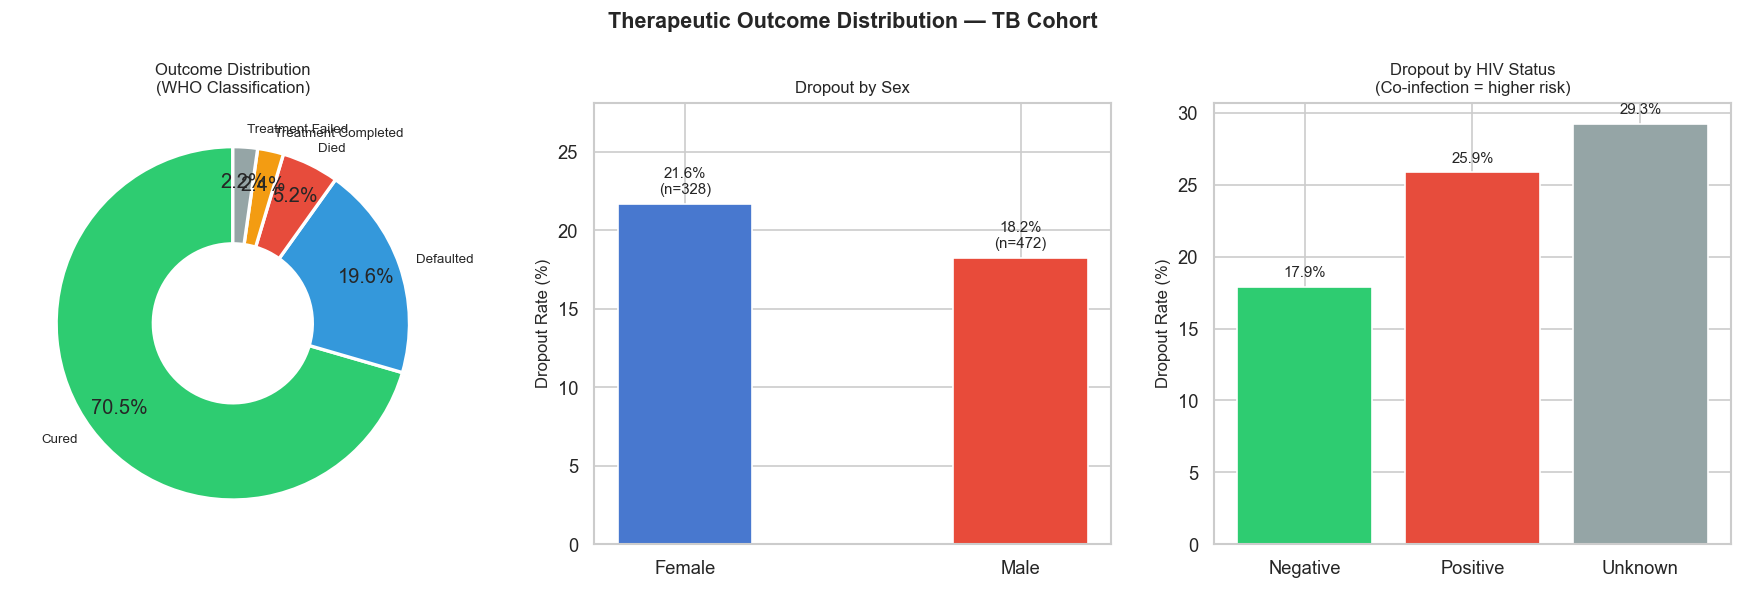

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Therapeutic Outcome Distribution — TB Cohort', fontsize=13, fontweight='bold')

# ── 1a. Donut chart de outcomes ──────────────────────────────
outcomes = df['outcome'].value_counts()
colors = ['#2ECC71', '#3498DB', '#E74C3C', '#F39C12', '#95A5A6']
wedges, texts, autotexts = axes[0].pie(
    outcomes.values, labels=outcomes.index, autopct='%1.1f%%',
    colors=colors, startangle=90, pctdistance=0.8,
    wedgeprops={'width': 0.55, 'edgecolor': 'white', 'linewidth': 2}
)
[t.set_fontsize(8) for t in texts]
axes[0].set_title('Outcome Distribution\n(WHO Classification)', fontsize=10)

# ── 1b. Dropout by sex ───────────────────────────────────────
pivot_sex = df.groupby('sex')['dropout_label'].agg(['mean', 'count']).reset_index()
pivot_sex['dropout_pct'] = pivot_sex['mean'] * 100
bars = axes[1].bar(pivot_sex['sex'], pivot_sex['dropout_pct'],
                    color=['#4878CF', '#E84B3A'], width=0.4, edgecolor='white')
for bar, (_, row) in zip(bars, pivot_sex.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                  f'{row["dropout_pct"]:.1f}%\n(n={int(row["count"])})',
                  ha='center', va='bottom', fontsize=9)
axes[1].set_ylabel('Dropout Rate (%)', fontsize=10)
axes[1].set_title('Dropout by Sex', fontsize=10)
axes[1].set_ylim(0, max(pivot_sex['dropout_pct']) * 1.3)

# ── 1c. Dropout by HIV status ────────────────────────────────
pivot_hiv = df.groupby('hiv_status')['dropout_label'].mean().reset_index()
pivot_hiv['dropout_pct'] = pivot_hiv['dropout_label'] * 100
hiv_colors = {'Negative': '#2ECC71', 'Positive': '#E74C3C', 'Unknown': '#95A5A6'}
axes[2].bar(pivot_hiv['hiv_status'], pivot_hiv['dropout_pct'],
             color=[hiv_colors.get(h, 'gray') for h in pivot_hiv['hiv_status']],
             edgecolor='white')
for i, (_, row) in enumerate(pivot_hiv.iterrows()):
    axes[2].text(i, row['dropout_pct'] + 0.5, f'{row["dropout_pct"]:.1f}%',
                  ha='center', va='bottom', fontsize=9)
axes[2].set_ylabel('Dropout Rate (%)', fontsize=10)
axes[2].set_title('Dropout by HIV Status\n(Co-infection = higher risk)', fontsize=10)

plt.tight_layout()
plt.savefig('../figures/01_outcomes_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Regional Analysis — Where is the problem?

=== REGIONAL STATISTICS ===
 region  n_patients  dropout_pct  avg_distance  hiv_pct  avg_attendance
   West         161        27.95         35.22    18.01           77.33
   East         176        23.30         32.36    16.48           81.82
  North         157        21.66         41.06    18.47           77.39
  South         149        14.09         16.27     9.40           83.22
Central         157        10.19         10.49     9.55           86.31


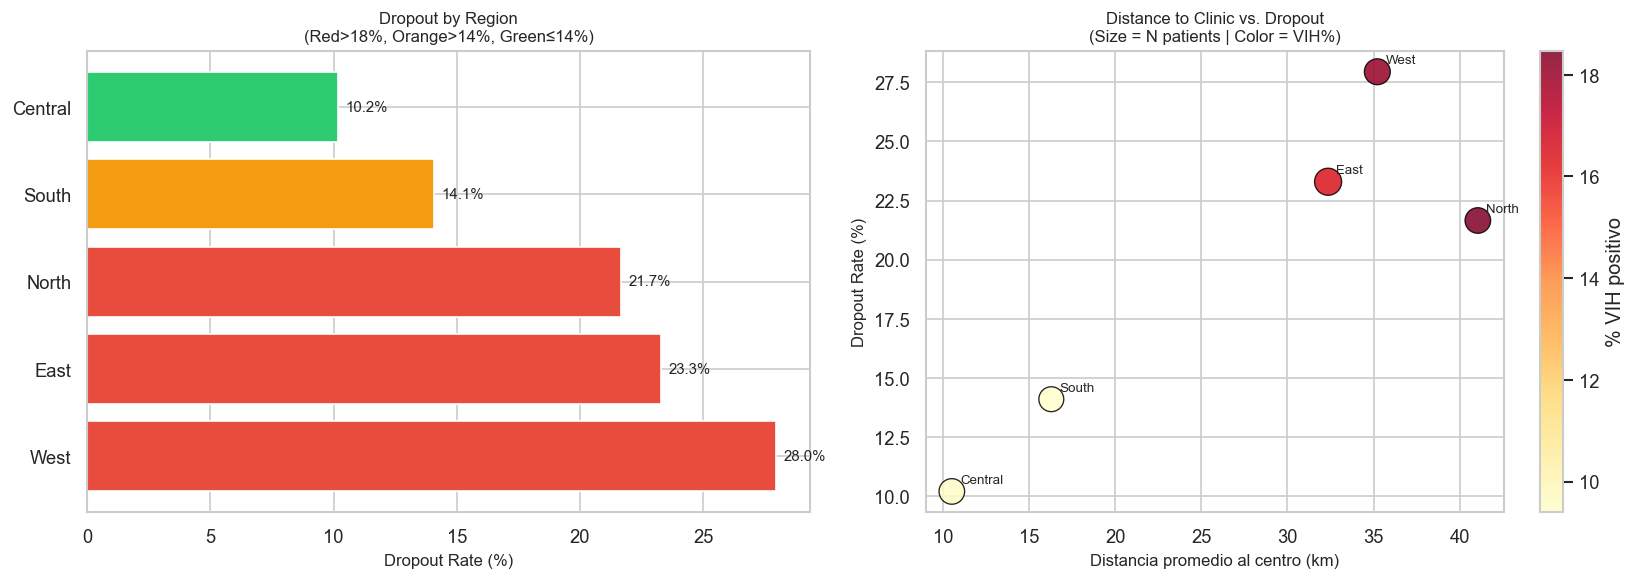

In [3]:
region_stats = df.groupby('region').agg(
    n_patients     = ('patient_id', 'count'),
    dropout_rate   = ('dropout_label', 'mean'),
    avg_distance   = ('distance_km', 'mean'),
    hiv_rate       = ('hiv_positive', 'mean'),
    avg_attendance = ('attendance_rate_pct', 'mean'),
).reset_index()
region_stats['dropout_pct'] = region_stats['dropout_rate'] * 100
region_stats['hiv_pct'] = region_stats['hiv_rate'] * 100

print('=== REGIONAL STATISTICS ===')
print(region_stats[['region', 'n_patients', 'dropout_pct', 'avg_distance',
                      'hiv_pct', 'avg_attendance']]
      .sort_values('dropout_pct', ascending=False).to_string(index=False))

# ── Region × indicators heatmap ─────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Dropout rate bars by region
rs = region_stats.sort_values('dropout_pct', ascending=False)
colors_region = ['#E74C3C' if p > 18 else '#F39C12' if p > 14 else '#2ECC71'
                  for p in rs['dropout_pct']]
bars = ax1.barh(rs['region'], rs['dropout_pct'], color=colors_region, edgecolor='white')
for bar, pct in zip(bars, rs['dropout_pct']):
    ax1.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
              f'{pct:.1f}%', va='center', fontsize=9)
ax1.set_xlabel('Dropout Rate (%)', fontsize=10)
ax1.set_title('Dropout by Region\n(Red>18%, Orange>14%, Green≤14%)', fontsize=10)

# Scatter: distance vs dropout (colored by HIV rate)
sc = ax2.scatter(region_stats['avg_distance'], region_stats['dropout_pct'],
                  s=region_stats['n_patients']*1.5,
                  c=region_stats['hiv_pct'], cmap='YlOrRd',
                  alpha=0.85, edgecolors='black', linewidth=0.8)
for _, row in region_stats.iterrows():
    ax2.annotate(row['region'],
                  (row['avg_distance'], row['dropout_pct']),
                  textcoords='offset points', xytext=(5, 5), fontsize=8)
plt.colorbar(sc, ax=ax2, label='% VIH positivo')
ax2.set_xlabel('Distancia promedio al centro (km)', fontsize=10)
ax2.set_ylabel('Dropout Rate (%)', fontsize=10)
ax2.set_title('Distance to Clinic vs. Dropout\n(Size = N patients | Color = VIH%)',
               fontsize=10)

plt.tight_layout()
plt.savefig('../figures/02_regional_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Temporal Analysis — In which month is dropout highest?

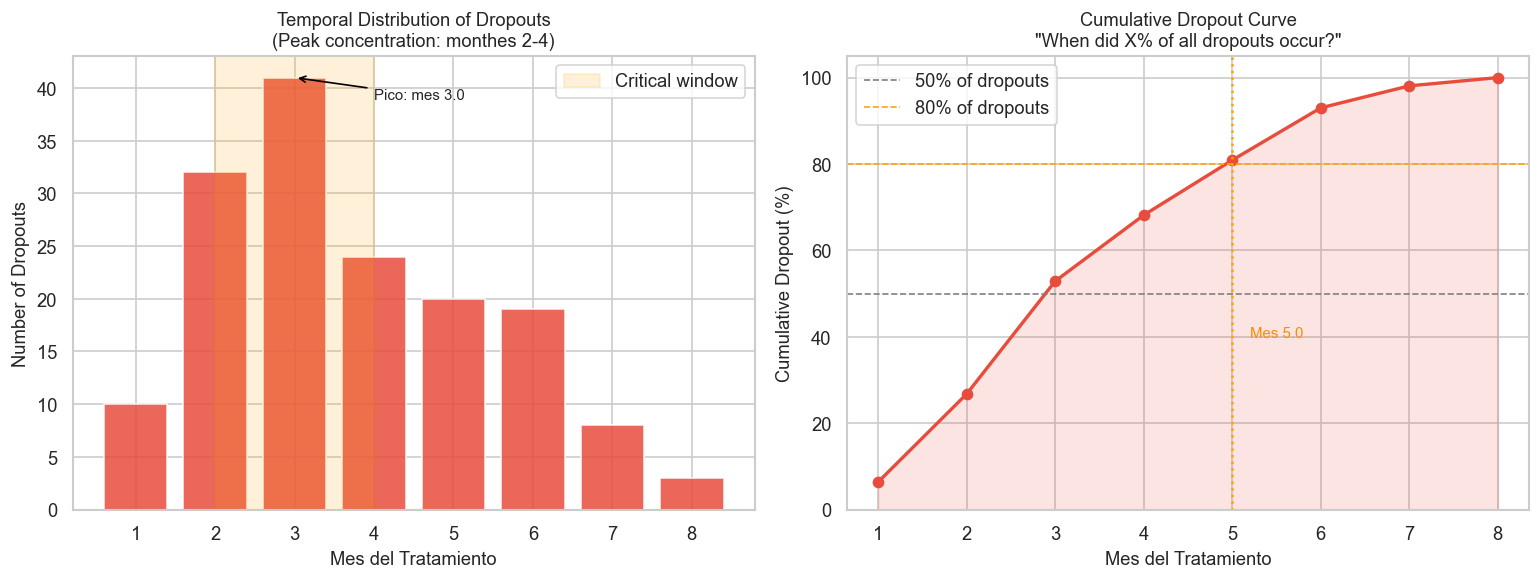


💡 Insight clave:
   68% of all dropouts occur within the first 4 months.
   → Preventive interventions should focus on this period.


In [4]:
dropouts = df[df['dropout_label'] == 1].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Histogram: dropout month ────────────────────────────────
dropout_months = dropouts['dropout_month'].dropna()
month_counts = dropout_months.value_counts().sort_index()

axes[0].bar(month_counts.index, month_counts.values,
             color='#E74C3C', alpha=0.85, edgecolor='white')
axes[0].set_xlabel('Mes del Tratamiento', fontsize=11)
axes[0].set_ylabel('Number of Dropouts', fontsize=11)
axes[0].set_title('Temporal Distribution of Dropouts\n(Peak concentration: monthes 2-4)',
                   fontsize=11)
axes[0].axvspan(2, 4, alpha=0.15, color='orange', label='Critical window')
axes[0].legend()

# Anotar el pico
peak_month = month_counts.idxmax()
axes[0].annotate(f'Pico: mes {peak_month}',
                  xy=(peak_month, month_counts.max()),
                  xytext=(peak_month + 1, month_counts.max() * 0.95),
                  arrowprops=dict(arrowstyle='->', color='black'),
                  fontsize=9)

# ── Cumulative dropout curve ─────────────────────────────────
cumulative = month_counts.cumsum() / month_counts.sum() * 100
axes[1].plot(cumulative.index, cumulative.values, 'o-',
              color='#E74C3C', linewidth=2, markersize=6)
axes[1].axhline(50, color='gray', linestyle='--', lw=1, label='50% of dropouts')
axes[1].axhline(80, color='orange', linestyle='--', lw=1, label='80% of dropouts')
axes[1].fill_between(cumulative.index, cumulative.values, alpha=0.15, color='#E74C3C')
axes[1].set_xlabel('Mes del Tratamiento', fontsize=11)
axes[1].set_ylabel('Cumulative Dropout (%)', fontsize=11)
axes[1].set_title('Cumulative Dropout Curve\n"When did X% of all dropouts occur?"',
                   fontsize=11)
axes[1].legend()
axes[1].set_ylim(0, 105)

# Annotate where 80% falls
month_80 = cumulative[cumulative >= 80].index[0] if any(cumulative >= 80) else None
if month_80:
    axes[1].axvline(month_80, color='orange', linestyle=':', lw=1.5)
    axes[1].text(month_80 + 0.2, 40, f'Mes {month_80}', color='darkorange', fontsize=9)

plt.tight_layout()
plt.savefig('../figures/03_temporal_dropout_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n💡 Insight clave:')
print(f'   {cumulative.iloc[3]:.0f}% of all dropouts occur within the first 4 months.')
print(f'   → Preventive interventions should focus on this period.')

## 4. Risk Factors — Boxplots with Statistical Tests

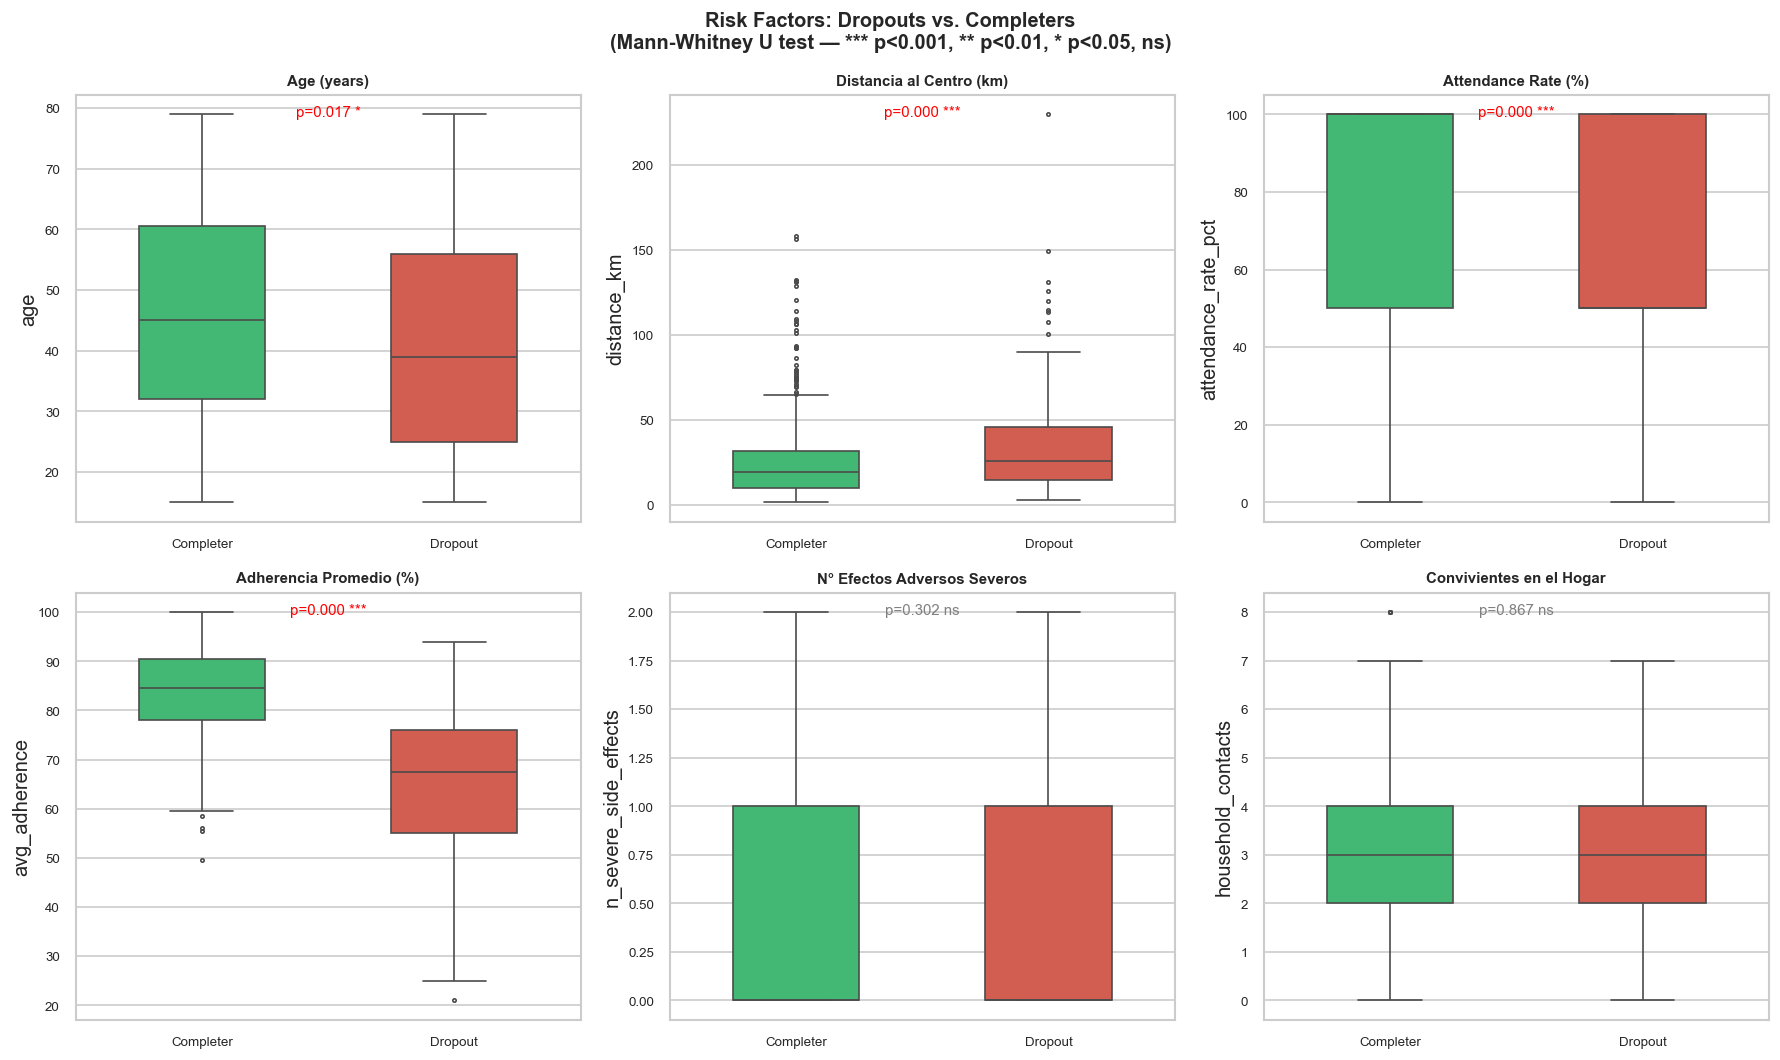

In [5]:
from scipy.stats import mannwhitneyu, chi2_contingency

continuous_vars = [
    ('age', 'Age (years)'),
    ('distance_km', 'Distancia al Centro (km)'),
    ('attendance_rate_pct', 'Attendance Rate (%)'),
    ('avg_adherence', 'Adherencia Promedio (%)'),
    ('n_severe_side_effects', 'N° Efectos Adversos Severos'),
    ('household_contacts', 'Convivientes en el Hogar'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Risk Factors: Dropouts vs. Completers\n'
             '(Mann-Whitney U test — *** p<0.001, ** p<0.01, * p<0.05, ns)',
             fontsize=12, fontweight='bold')

palette = {'Completer': '#2ECC71', 'Dropout': '#E74C3C'}

df_plot = df.copy()
df_plot['Outcome'] = df_plot['dropout_label'].map({0: 'Completer', 1: 'Dropout'})

for ax, (var, label) in zip(axes.flat, continuous_vars):
    if var not in df.columns:
        ax.set_visible(False)
        continue

    grp0 = df[df['dropout_label'] == 0][var].dropna()
    grp1 = df[df['dropout_label'] == 1][var].dropna()

    stat, pval = mannwhitneyu(grp0, grp1, alternative='two-sided')
    sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'

    sns.boxplot(data=df_plot, x='Outcome', y=var,
                palette=palette, width=0.5, ax=ax,
                fliersize=2, linewidth=1)

    # Barra de significancia
    y_max = df[var].quantile(0.95)
    ax.annotate(f'p={pval:.3f} {sig}',
                 xy=(0.5, 0.95), xycoords='axes fraction',
                 ha='center', fontsize=9,
                 color='red' if sig != 'ns' else 'gray')

    ax.set_title(label, fontsize=9, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('../figures/04_risk_factors_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Categorical Variables Analysis — Dropout Rates

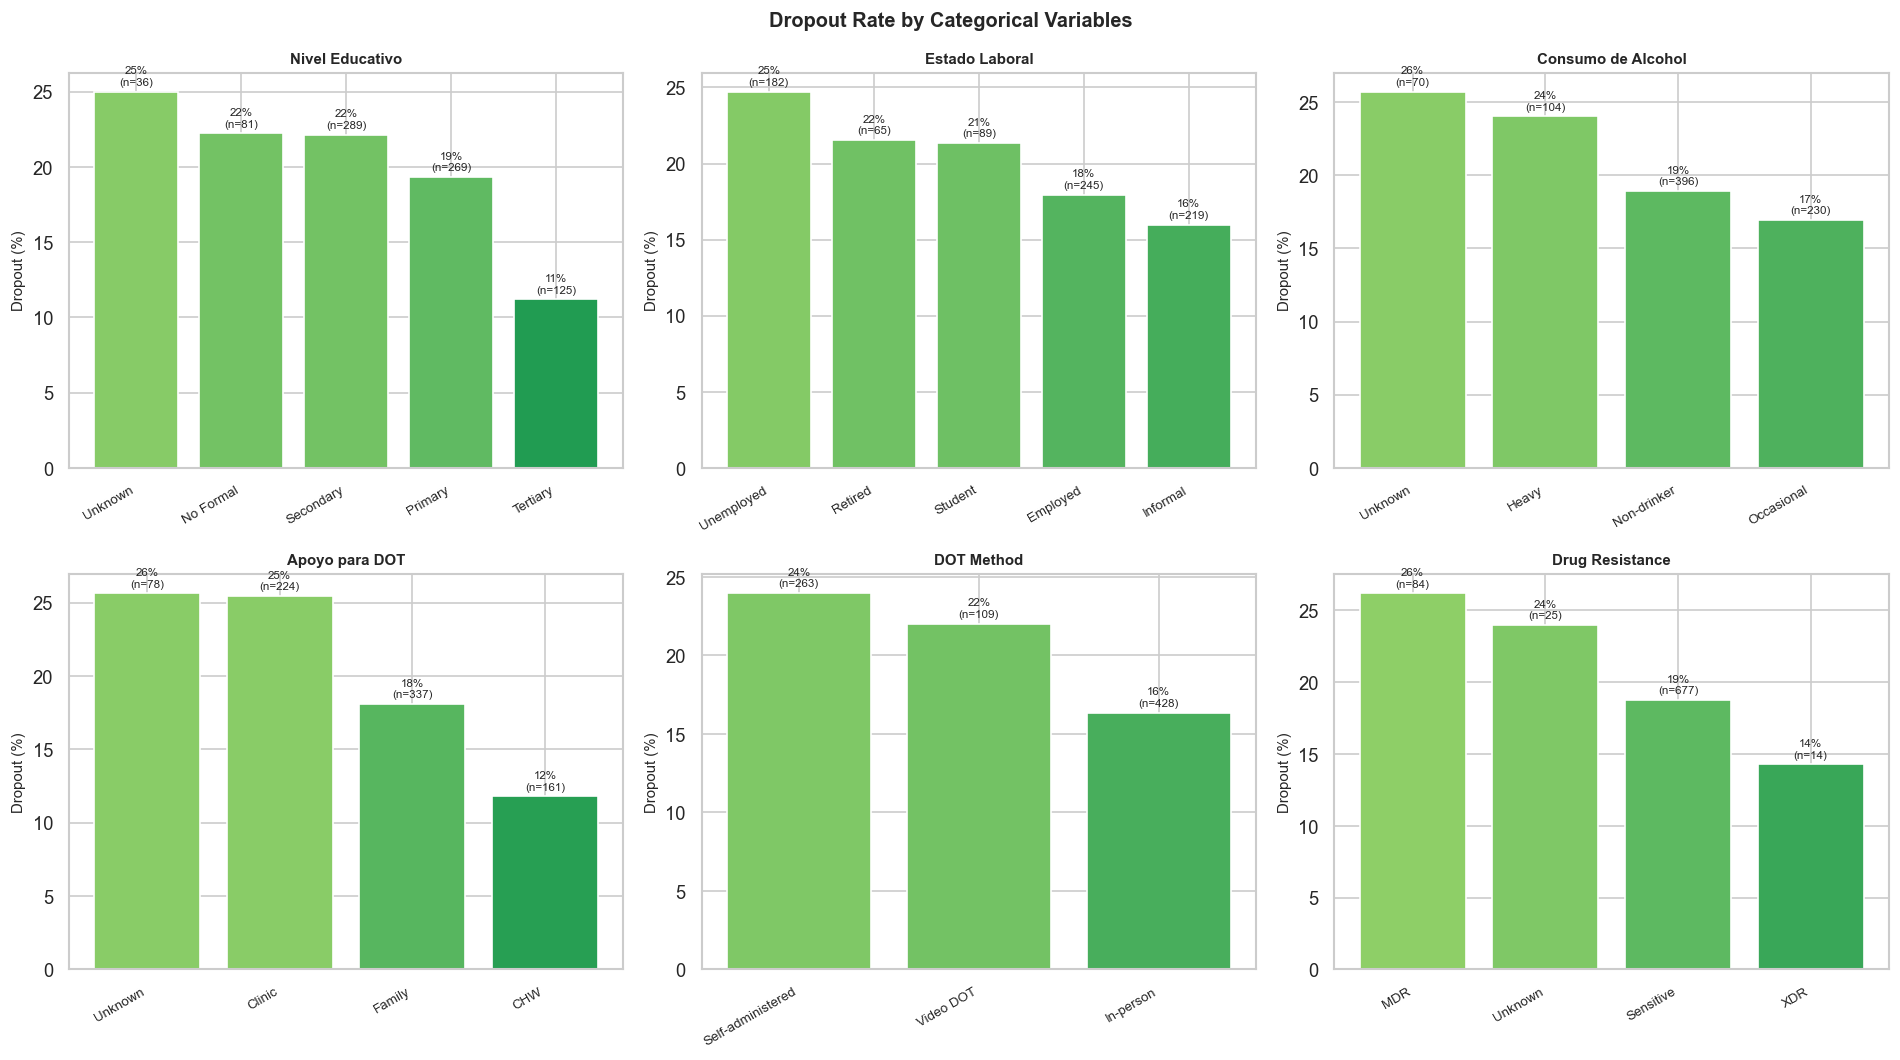

In [6]:
cat_vars = [
    ('education_level', 'Nivel Educativo'),
    ('employment_status', 'Estado Laboral'),
    ('alcohol_use', 'Consumo de Alcohol'),
    ('supporter', 'Apoyo para DOT'),
    ('dot_method', 'DOT Method'),
    ('drug_resistance', 'Drug Resistance'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Dropout Rate by Categorical Variables', fontsize=12, fontweight='bold')

for ax, (var, label) in zip(axes.flat, cat_vars):
    if var not in df.columns:
        ax.set_visible(False)
        continue

    pivot = df.groupby(var).agg(
        dropout_rate=('dropout_label', 'mean'),
        n=('dropout_label', 'count')
    ).reset_index().sort_values('dropout_rate', ascending=False)
    pivot['dropout_pct'] = pivot['dropout_rate'] * 100

    bar_colors = plt.cm.RdYlGn_r(pivot['dropout_rate'].values)
    bars = ax.bar(range(len(pivot)), pivot['dropout_pct'],
                   color=bar_colors, edgecolor='white')
    ax.set_xticks(range(len(pivot)))
    ax.set_xticklabels(pivot[var], rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('Dropout (%)', fontsize=9)
    ax.set_title(label, fontsize=9, fontweight='bold')

    for bar, (_, row) in zip(bars, pivot.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{row["dropout_pct"]:.0f}%\n(n={row["n"]})',
                 ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('../figures/05_categorical_dropout_rates.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Correlation Matrix

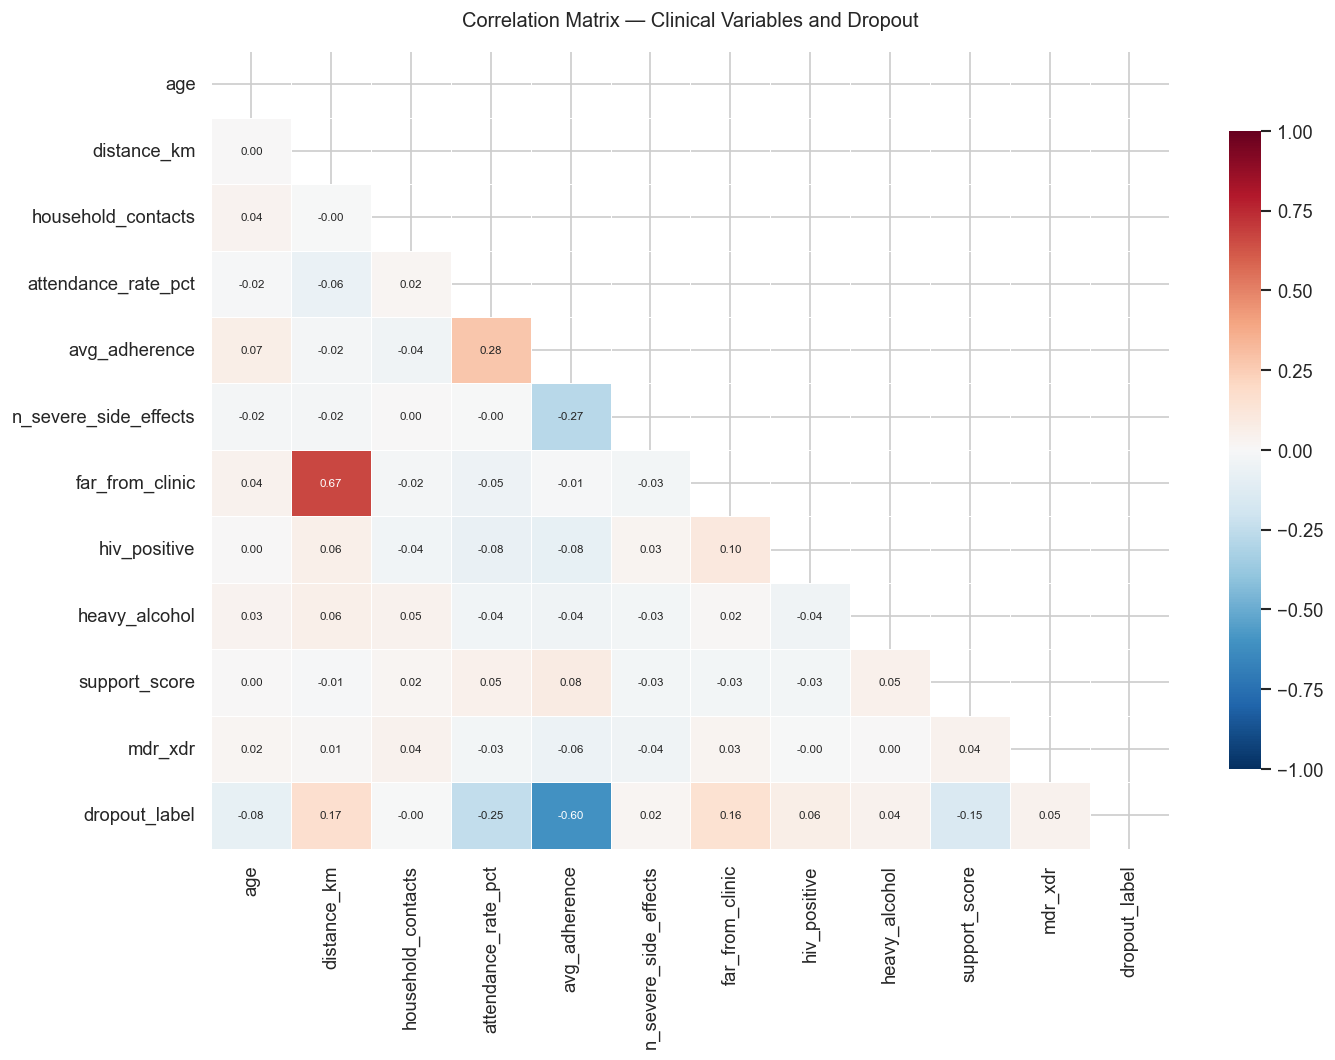


Top correlaciones con dropout_label:
  avg_adherence                 : -0.602  ⬇ protective
  attendance_rate_pct           : -0.248  ⬇ protective
  distance_km                   : +0.169  ⬆ risk factor
  far_from_clinic               : +0.155  ⬆ risk factor
  support_score                 : -0.149  ⬇ protective
  age                           : -0.083  ⬇ protective
  hiv_positive                  : +0.065  ⬆ risk factor
  mdr_xdr                       : +0.046  ⬆ risk factor


In [7]:
corr_cols = [
    'age', 'distance_km', 'household_contacts',
    'attendance_rate_pct', 'avg_adherence', 'n_severe_side_effects',
    'far_from_clinic', 'hiv_positive', 'heavy_alcohol',
    'low_attendance', 'support_score', 'mdr_xdr', 'dropout_label'
]
corr_cols = [c for c in corr_cols if c in df.columns]

corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8},
    annot_kws={'size': 7}
)
ax.set_title('Correlation Matrix — Clinical Variables and Dropout',
              fontsize=12, pad=15)
plt.tight_layout()
plt.savefig('../figures/06_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop correlaciones con dropout_label:')
corr_target = corr['dropout_label'].drop('dropout_label').sort_values(key=abs, ascending=False)
for col, val in corr_target.head(8).items():
    direction = '⬆ risk factor' if val > 0 else '⬇ protective'
    print(f'  {col:30s}: {val:+.3f}  {direction}')

## 7. Kaplan-Meier Analysis — Time to Dropout

Kaplan-Meier is the standard epidemiological method for time-to-event data with censored observations (patients who did not default but whose follow-up ended before treatment completion).

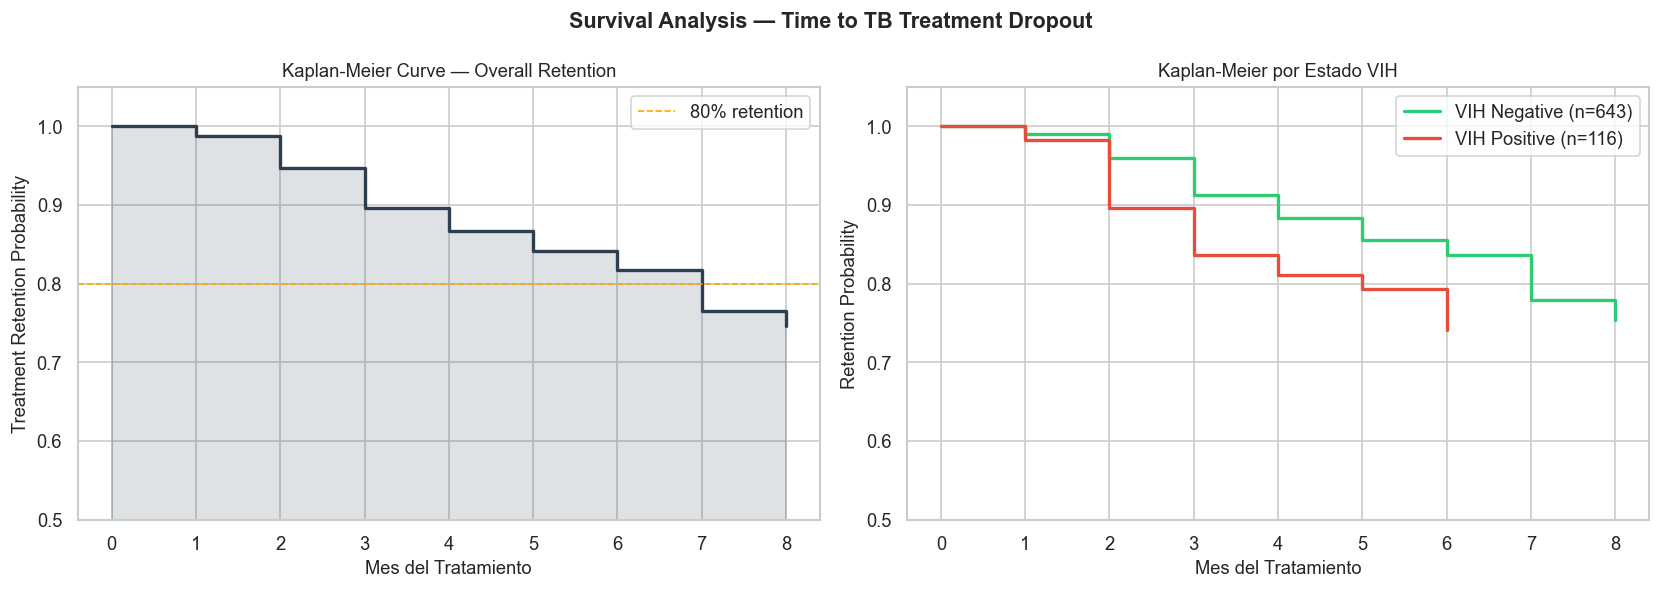

In [8]:
# Kaplan-Meier manual (sin lifelines para evitar dependencia)
# Event = dropout, time = dropout_month or total duration

def kaplan_meier(times, events):
    """Calcula la curva de supervivencia K-M manualmente."""
    df_km = pd.DataFrame({'T': times, 'E': events}).sort_values('T')
    unique_times = sorted(df_km[df_km['E'] == 1]['T'].unique())

    n = len(df_km)
    km_times = [0]
    km_surv = [1.0]
    S = 1.0

    for t in unique_times:
        n_risk = (df_km['T'] >= t).sum()
        n_events = ((df_km['T'] == t) & (df_km['E'] == 1)).sum()
        if n_risk > 0:
            S = S * (1 - n_events / n_risk)
        km_times.append(t)
        km_surv.append(S)

    return km_times, km_surv


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── KM global ────────────────────────────────────────────────
df_km_all = df.copy()
df_km_all['T'] = df_km_all['dropout_month'].fillna(df_km_all['expected_months'])
df_km_all['E'] = df_km_all['dropout_label']

t_all, s_all = kaplan_meier(df_km_all['T'], df_km_all['E'])
ax1.step(t_all, s_all, where='post', color='#2C3E50', linewidth=2)
ax1.fill_between(t_all, s_all, alpha=0.15, color='#2C3E50', step='post')
ax1.axhline(0.8, color='orange', linestyle='--', lw=1, label='80% retention')
ax1.set_xlabel('Mes del Tratamiento', fontsize=11)
ax1.set_ylabel('Treatment Retention Probability', fontsize=11)
ax1.set_title('Kaplan-Meier Curve — Overall Retention', fontsize=11)
ax1.set_ylim(0.5, 1.05)
ax1.legend()

# ── KM por grupo VIH ─────────────────────────────────────────
colors_hiv = {'Negative': '#2ECC71', 'Positive': '#E74C3C', 'Unknown': '#95A5A6'}

for hiv_grp in ['Negative', 'Positive']:
    subset = df_km_all[df_km_all['hiv_status'] == hiv_grp]
    t_g, s_g = kaplan_meier(subset['T'], subset['E'])
    ax2.step(t_g, s_g, where='post', color=colors_hiv[hiv_grp],
              linewidth=2, label=f'VIH {hiv_grp} (n={len(subset)})')

ax2.set_xlabel('Mes del Tratamiento', fontsize=11)
ax2.set_ylabel('Retention Probability', fontsize=11)
ax2.set_title('Kaplan-Meier por Estado VIH', fontsize=11)
ax2.set_ylim(0.5, 1.05)
ax2.legend()

plt.suptitle('Survival Analysis — Time to TB Treatment Dropout',
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/07_kaplan_meier.png', dpi=150, bbox_inches='tight')
plt.show()